In [ ]:
#=================================================================================================
# Libraries:
# 1. pandas — to load, clean, and organize the CSV data into tables you can analyze easily.
# 2. matplotlib — to create the bar chart, box plots, and histogram plots.
# 3. scipy — to calculate the Pearson correlation and other statistical values.
# 4. numpy — to handle numerical operations efficiently behind the scenes.
# 5. seaborn — to make the plots look cleaner and more polished with less code.
#=================================================================================================
# Types of Plots:
# 1. Bar Chart: To compare the average values of a specific column across different categories.
# 2. Box Plot: To visualize the distribution of a numerical column and identify outliers
# 3. Histogram: To show the frequency distribution of a numerical column and understand its shape.
# 4. Pearson Correlation: To measure the strength and direction of the linear relationship between two numerical columns.
#=================================================================================================
# Graphs we can make now - Transcribed from 08/04/2026 Meeting:
# Histogram - Count on y axis and {Variable} on x axis - At least 5 Figures

# https://chatgpt.com/c/69dd0506-45f4-8392-9f9b-efca2313721a

In [1]:
import pandas as pd

file_path = "Complete Extraction Results.xlsx"

# Open the Excel file
excel_file = pd.ExcelFile(file_path, engine="openpyxl")

# Show all sheet names
print("Available sheets:")
for i, sheet in enumerate(excel_file.sheet_names, start=1):
    print(f"{i}. {sheet}")

# Select a sheet by number
choice = int(input("Enter sheet number: "))
selected_sheet = excel_file.sheet_names[choice - 1]

# Read that sheet
df = pd.read_excel(file_path, sheet_name=selected_sheet, engine="openpyxl", header=1)

print(f"\nLoaded sheet: {selected_sheet}")
print(df.head())
print(f"\nColumns in the sheet: {df.columns.tolist()[0:10]}")  # Show first 10 columns for brevity

# Make dictionary: key -> column name
column_dict = {i: col for i, col in enumerate(df.columns, start=1)}

print("\nColumn dictionary:")
for k, v in column_dict.items():
    print(f"{k}: {v}")


Available sheets:
1. Structure
2. Graphs (6 Types)
3. ReadMe
4. Extra


Enter sheet number:  2



Loaded sheet: Graphs (6 Types)
   datapoint_id  id exact_polymer_name                         Polymer Family  \
0           NaN  A1          PDPPSe-12  Diketopyrrolopyrrole (DPP) derivative   
1           NaN  A1          PDPPSe-12  Diketopyrrolopyrrole (DPP) derivative   
2           NaN  A1          PDPPSe-12  Diketopyrrolopyrrole (DPP) derivative   
3           NaN  A1          PDPPSe-12  Diketopyrrolopyrrole (DPP) derivative   
4           NaN  A1          PDPPSe-12  Diketopyrrolopyrrole (DPP) derivative   

   Chemical Structure (Image) Repeating Unit Formula  \
0                         NaN         C53H78N2O2S2Se   
1                         NaN         C53H78N2O2S2Se   
2                         NaN         C53H78N2O2S2Se   
3                         NaN         C53H78N2O2S2Se   
4                         NaN         C53H78N2O2S2Se   

   Molecular Weight of the Repeating Unit (g/mol)  \
0                                          918.31   
1                                     

# Figures: Count Vs {Variable}

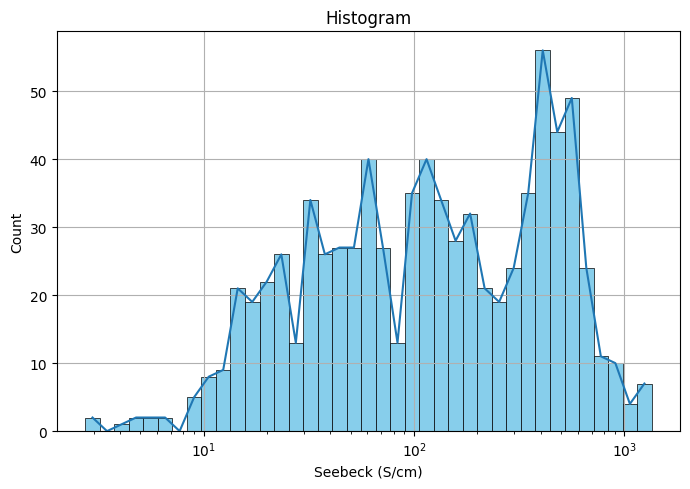

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

col_name = column_dict[49]
x = pd.to_numeric(df[col_name], errors='coerce')
x = x.replace([np.inf, -np.inf], np.nan).dropna()
x = x[x > 0]

# Log-spaced bins
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 40)

# Histogram counts
counts, bin_edges = np.histogram(x, bins=bins)

# Bin centers
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])   # better for log scale

plt.figure(figsize=(7, 5))

# Histogram
plt.hist(x, bins=bins, color='skyblue', edgecolor='black', linewidth=0.5)

# Line connecting bar tips
plt.plot(bin_centers, counts, linewidth=1.5)
plt.grid()

plt.xscale('log')
plt.xlabel("Seebeck (S/cm)")
plt.ylabel('Count')
plt.title("Histogram")

plt.tight_layout()
plt.show()

# Dataset Stats - Need to put in paper

In [18]:
col_name = column_dict[62]

# Convert column to numeric and ignore non-numeric cells
x = pd.to_numeric(df[col_name], errors='coerce')

# Sum all values
total = x.sum()

print("Column:", col_name)
print("Sum =", total)

Column: Number of Additional Papers Covered
Sum = 64.0
